In [13]:
import sashimi_c
import numpy as np

pr = sashimi_c.subhalo_properties()
ma = np.arange(1, 4)
zacc = np.arange(4, 8)
Na = pr.Na_calc(ma, zacc, 1e12)
print("ma.shape", ma.shape)
print("zacc.shape", zacc.shape)
print("Na.shape", Na.shape)

ma.shape (3,)
zacc.shape (4,)
Na.shape (4, 3)


In [12]:
ma = np.arange(1, 13).reshape(4, 3)
zacc = np.arange(4, 8)
Na = pr.Na_calc(ma, zacc, 1e12)
print("ma.shape", ma.shape)
print("zacc.shape", zacc.shape)
print("Na.shape", Na.shape)

ma.shape (4, 3)
zacc.shape (4,)
Na.shape (4, 3)


In [26]:
zacc = np.random.rand(2)
ma = np.random.rand(3)
# reshape ma to be ma.shape = (len(zacc), len(ma))
ma = zacc[:, np.newaxis] + ma[np.newaxis, :]
print("zacc", zacc)
print("ma", ma)
Na_broadcast = pr.Na_calc(ma, zacc, 1e12)
print("Na", Na_broadcast)
Na_for = [pr.Na_calc(m, zacc, 1e12) for m in ma]
Na_for = np.array(Na_for)
print("Na_for", Na_for)

zacc [0.33181084 0.24056249]
ma [[1.0591327  0.58237069 0.46871562]
 [0.96788435 0.49112234 0.37746727]]
Na [[2.13531268e+09 3.72096772e+09 4.55281519e+09]
 [2.32214440e+09 4.36056133e+09 5.56942756e+09]]
Na_for [[[2.13531268e+09 3.72096772e+09 4.55281519e+09]
  [2.13587620e+09 3.72193240e+09 4.55398817e+09]]

 [[2.32153340e+09 4.35943667e+09 5.56800179e+09]
  [2.32214440e+09 4.36056133e+09 5.56942756e+09]]]


In [36]:
# check if np.sum or python sum is faster
arr = np.random.rand(1000000)
get_generator = lambda : (x for x in arr)
%timeit np.sum(arr)
%timeit sum(get_generator())
assert np.allclose(np.sum(arr), sum(get_generator()))

168 μs ± 255 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
103 ms ± 1.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


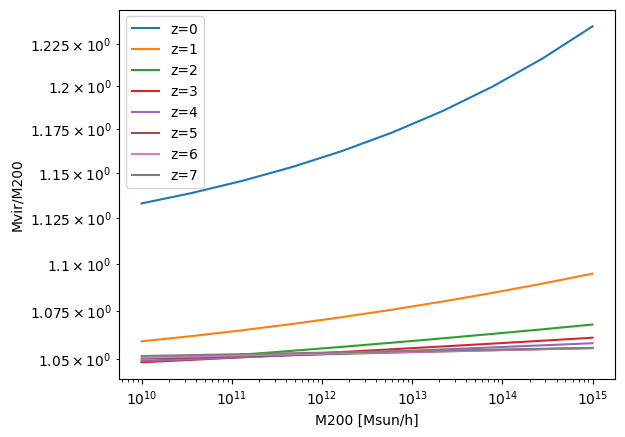

In [40]:
import numpy as np
import matplotlib.pyplot as plt

m200 = np.logspace(10, 15, 10)
for z in np.arange(0, 8):
    mvir = pr.Mvir_from_M200_fit(m200, z)
    plt.plot(m200, mvir/m200, label=f"z={z}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("M200 [Msun/h]")
plt.ylabel("Mvir/M200")
plt.legend()
plt.show()